In [2]:
import os
import torch
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import math
from pathlib import Path
import pandas as pd
import seaborn as sns

# Add project root to path
# PROJECT_ROOT = Path(__file__).resolve().parent.parent
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.join(os.getcwd(), ".."), ".."))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    print(f"Added {PROJECT_ROOT} to Python path")

from neural_networks.drm import DiscreteRepresentationsModel
from neural_networks.drm_viz import visualize_model_architecture, \
    visualize_state_space, analyze_state_transitions, visualize_transition_matrices
from data_generation.models.tech_substitution import TechnologySubstitution, TechSubNumericalSolver
from data_generation.simulations.grid import tangent_transformation

Added /home/julian/tuberlin/projects/mdp-world-model to Python path


In [3]:
def load_model(model_path):
    """
    Load a trained DRM model from a checkpoint file
    
    Args:
        model_path: Path to the checkpoint file
        
    Returns:
        model: The loaded model
        config: The model configuration
    """
    # Load the saved model with weights_only=True for security
    checkpoint = torch.load(model_path, map_location=torch.device('cpu'), weights_only=True)
    
    # Extract configuration
    config = checkpoint.get('config', {})
    
    # Print configuration in a more readable format
    print("Model configuration:")
    config_str = ", ".join(f"{k}={v}" for k, v in config.items())
    print(f" {config_str}")
    
    # Detect predictor type from state dict
    predictor_type = 'control_gate'  # default
    state_dict_keys = set(checkpoint['model_state_dict'].keys())
    if any('predictor.interaction' in key for key in state_dict_keys):
        predictor_type = 'bilinear'
        print(f" predictor_type: bilinear")
    elif any('predictor.predictor.' in key for key in state_dict_keys):
        predictor_type = 'standard'
        print(f" predictor_type: standard")
    
    # Detect value_dim from state dict
    value_dim = 1  # default
    for key, param in checkpoint['model_state_dict'].items():
        if key == 'value_net.2.bias':
            value_dim = param.shape[0]
            print(f" value_dim: {value_dim}")
            break
    
    # Detect Gumbel softmax usage
    use_gumbel = False
    initial_temp = 1.0
    min_temp = 0.1
    
    # Detect target encoder usage
    use_target_encoder = any('target_encoder.' in key for key in state_dict_keys)
    if use_target_encoder:
        print(f" use_target_encoder: True")
    ema_decay = 0.996  # default value
    
    # Try to get additional parameters from config if available
    if isinstance(config, dict):
        use_gumbel = config.get('use_gumbel', use_gumbel)
        initial_temp = config.get('initial_temp', initial_temp)
        min_temp = config.get('min_temp', min_temp)
        ema_decay = config.get('ema_decay', ema_decay)
        
        # Print detected additional parameters
        if use_gumbel:
            print(f" use_gumbel: True, initial_temp: {initial_temp}, min_temp: {min_temp}")
        if use_target_encoder:
            print(f" ema_decay: {ema_decay}")
    
    # Recreate the model architecture
    model = DiscreteRepresentationsModel(
        obs_dim=config.get('obs_dim', 2),
        control_dim=config.get('control_dim', 1),
        value_dim=value_dim,
        num_states=config.get('num_states', 4),
        hidden_dim=config.get('hidden_dim', 64),
        predictor_type=predictor_type,
        use_gumbel=use_gumbel,
        initial_temp=initial_temp,
        min_temp=min_temp,
        use_target_encoder=use_target_encoder,
        ema_decay=ema_decay
    )
    
    # Load the state dict
    try:
        model.load_state_dict(checkpoint['model_state_dict'])
        print("\nModel weights loaded successfully")
    except Exception as e:
        print(f"\nWARNING: Error loading model weights: {e}")
        print("This might be due to architecture changes. Using model with randomly initialized weights.")
    
    # Set the model to evaluation mode
    model.eval()
    print(f"\nModel loaded successfully!")
    
    if 'epoch' in checkpoint:
        print(f"Trained for {checkpoint['epoch']+1} epochs")
    if 'val_loss' in checkpoint:
        print(f"Final validation loss: {checkpoint['val_loss']}")
    
    return model, config

In [71]:
folder1 = "20250325_target_grid"
#run_id = "target_ema1_b1_l0_e0_w0_lr1_r0_20250325_144326"
#run_id = "target_ema1_b1_l0_e0_w1_lr1_r0_20250325_145427"
#run_id = "target_ema0_b1_l1_e0_w0_lr1_r0_20250325_144626"
run_id = "target_ema1_b1_l1_e1_w1_lr1_r0_20250325_150726" # with entropy and less state loss weight

#folder1 = "20250325_target_entropydecay"
#run_id = "target_ema0_l1_e0_lr1_r0_20250325_193234"
#run_id = "target_ema1_l1_e1_lr1_r0_20250325_193232"

#folder1= "20250324_new_value"
# run_id= "newval_p0_lr0_e0_l0_b0_h1_r0_20250325_105625" # great result
# run_id = "newval_p0_lr2_e2_l1_b0_h1_r0_20250325_104124" # with high entropy
# run_id = "newval_p1_lr0_e0_l0_b1_h0_r0_20250325_102426"
#run_id = "newval_p1_lr1_e1_l2_b1_h0_r0_20250325_102434" #collapse

folder2 = "run_"+run_id
checkpoint = "10"
file_name_check = "drm_checkpoint_epoch"+checkpoint+"_"+run_id+".pt"
file_name_final = "drm_final_"+run_id+".pt"


model_path_check = Path(PROJECT_ROOT) / "neural_networks" / "output" / folder1 / folder2 / file_name_check
#model_path_final = Path(PROJECT_ROOT) / "neural_networks" / "output" / folder1 / folder2 / file_name_final

In [72]:
# Load the model
model_check, config = load_model(model_path_check)
#model_final, config = load_model(model_path_final)

Model configuration:
 obs_dim=2, control_dim=1, num_states=4, hidden_dim=64
 predictor_type: bilinear
 value_dim: 1
 use_target_encoder: True
 ema_decay: 0.996

Model weights loaded successfully

Model loaded successfully!
Trained for 10 epochs
Final validation loss: 0.22785690473392606


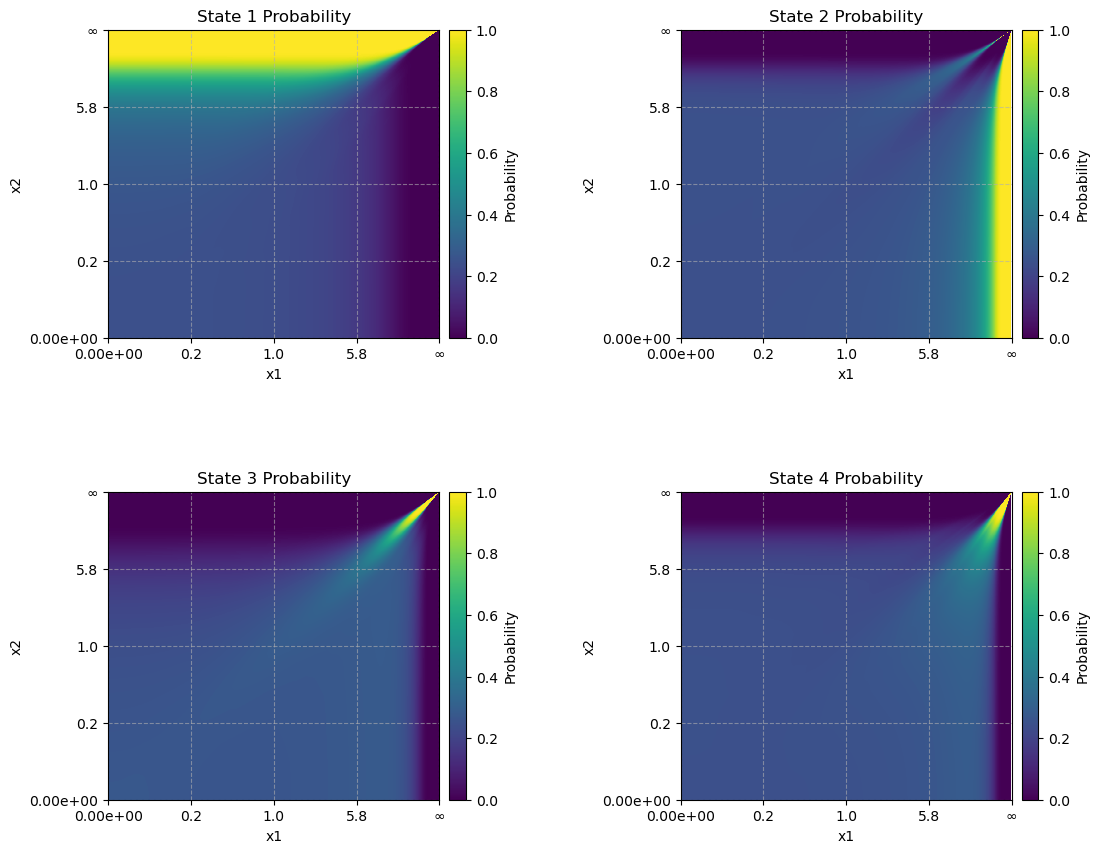

(<Figure size 1200x1000 with 8 Axes>,
 array([[<Axes: title={'center': 'State 1 Probability'}, xlabel='x1', ylabel='x2'>,
         <Axes: title={'center': 'State 2 Probability'}, xlabel='x1', ylabel='x2'>],
        [<Axes: title={'center': 'State 3 Probability'}, xlabel='x1', ylabel='x2'>,
         <Axes: title={'center': 'State 4 Probability'}, xlabel='x1', ylabel='x2'>]],
       dtype=object))

In [73]:
visualize_state_space(model_check)